In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import LabelEncoder
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import vit_b_16, ViT_B_16_Weights
from tqdm import tqdm
from PIL import Image

In [2]:
# === Config ===
train_csv = 'csv/train.csv'
val_csv = 'csv/val.csv'
test_csv = 'csv/test.csv'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [3]:
# === Dataset ===
class SeasonDataset(Dataset):
    def __init__(self, csv_file, transform=None, label_encoder=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform
        self.le = label_encoder or LabelEncoder()
        self.data['label_encoded'] = self.le.fit_transform(self.data['label'])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = os.path.join('', row['file_path'].replace("\\", "/"))
        label = row['label_encoded']
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

In [4]:
# === Transforms ===
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# === Label Encoder Shared ===
all_labels = pd.read_csv(train_csv)['label'].tolist()
label_encoder = LabelEncoder()
label_encoder.fit(all_labels)

# === Load Data ===
train_dataset = SeasonDataset(train_csv, transform, label_encoder)
val_dataset = SeasonDataset(val_csv, transform, label_encoder)
test_dataset = SeasonDataset(test_csv, transform, label_encoder)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=8, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

In [8]:
# === Model ===
# Load model
weights = ViT_B_16_Weights.DEFAULT
model = vit_b_16(weights=weights)

# Replace the head with dropout + linear
in_features = model.heads.head.in_features
model.heads.head = nn.Sequential(
    nn.Dropout(p=0.5),  # Add dropout here
    nn.Linear(in_features, len(label_encoder.classes_))
)
model = model.to(device)

# === Loss & Optimizer ===
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Warm-up over the first 5 epochs
def warmup_lambda(epoch):
    if epoch < 5:
        return (epoch + 1) / 5
    else:
        return 1.0

scheduler = LambdaLR(optimizer, lr_lambda=warmup_lambda)

# === Training Loop ===
def evaluate(model, dataloader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

In [9]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_acc = 0.0
epochs_no_improve = 0
patience = 5
epochs = 30

print("Training with full tracking...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = total = 0

    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # === Validation ===
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss = criterion(outputs, labels)
            val_running_loss += val_loss.item()

            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_running_loss
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train: Loss={train_loss:.4f}, Acc={train_acc:.4f} | "
          f"Val: Loss={val_loss:.4f}, Acc={val_acc:.4f}")

    # === Save best model ===
    if val_acc > best_val_acc:
        best_val_acc = val_acc
    
        # Save best model only
        os.makedirs("model", exist_ok=True)
        model_path = "model/seasonal_model_best_vit.pth"
        torch.save(model.state_dict(), model_path)
        print(f"Best model saved at Epoch {epoch+1}")
        
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epoch(s)")

    scheduler.step()

    # === Early stopping ===
    if epochs_no_improve >= patience:
        print("Early stopping triggered.")
        break

Training with full tracking...


100%|███████████████████████████████████████████████████████████████████████████████████| 62/62 [00:40<00:00,  1.53it/s]


Epoch 1/30 | Train: Loss=112.1932, Acc=0.3636 | Val: Loss=9.4441, Acc=0.5915
Best model saved at Epoch 1


100%|███████████████████████████████████████████████████████████████████████████████████| 62/62 [00:43<00:00,  1.44it/s]


Epoch 2/30 | Train: Loss=68.4544, Acc=0.6090 | Val: Loss=7.2367, Acc=0.6707
Best model saved at Epoch 2


...

Epoch 19/30 | Train: Loss=8.6886, Acc=0.9512 | Val: Loss=10.0303, Acc=0.6911
No improvement for 3 epoch(s)


100%|███████████████████████████████████████████████████████████████████████████████████| 62/62 [00:42<00:00,  1.48it/s]


Epoch 20/30 | Train: Loss=6.2455, Acc=0.9652 | Val: Loss=9.9468, Acc=0.6911
No improvement for 4 epoch(s)


100%|███████████████████████████████████████████████████████████████████████████████████| 62/62 [00:42<00:00,  1.47it/s]


Epoch 21/30 | Train: Loss=5.4358, Acc=0.9718 | Val: Loss=10.1541, Acc=0.6829
No improvement for 5 epoch(s)
Early stopping triggered.


In [10]:
# === Final Test Accuracy ===
test_acc = evaluate(model, test_loader)
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.7276


In [11]:
model.load_state_dict(torch.load('model/seasonal_model_best_vit.pth'))
model.eval()

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

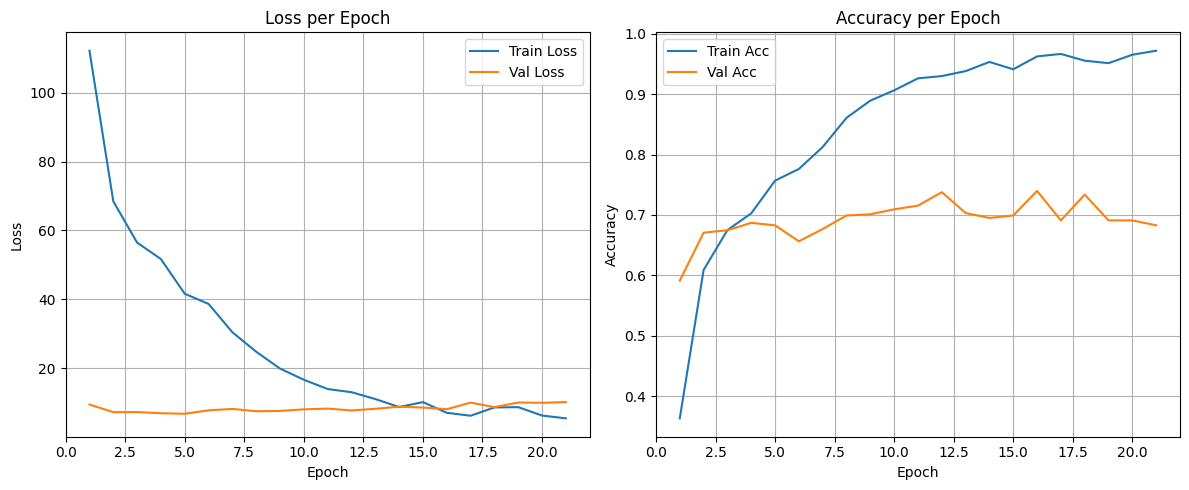

In [12]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Train Loss')
plt.plot(epochs_range, val_losses, label='Val Loss')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label='Train Acc')
plt.plot(epochs_range, val_accuracies, label='Val Acc')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

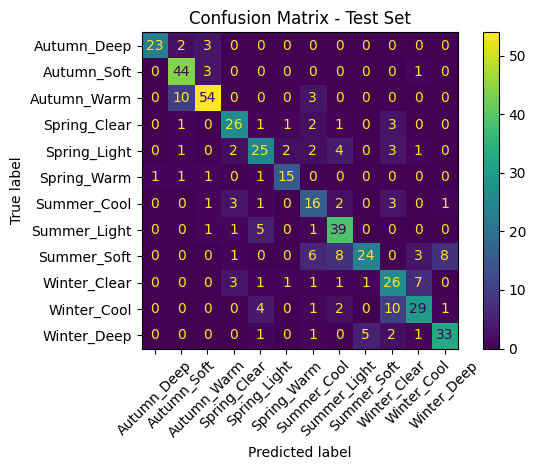

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.load_state_dict(torch.load("model/seasonal_model_best_vit.pth"))
model.eval()

all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())


cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.show()

In [18]:
# === Predict new image ===
from PIL import Image

def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    model.load_state_dict(torch.load("model/seasonal_model_best_convnexttiny.pth", map_location=device))
    model.eval()

    with torch.no_grad():
        output = model(image)
        pred_idx = output.argmax(dim=1).item()
        label = label_encoder.inverse_transform([pred_idx])[0]

    print(f"Predicted Seasonal Tone: {label}")
    return label

# === Example usage ===
predict_image("clustered_seasons_kmeans/Winter/Deep/14311.png")

Predicted Seasonal Tone: Winter_Deep


'Winter_Deep'